## Image Classification using ResNet-18

This notebook implements a deep learning pipeline for classifying environmental microorganism images using a pre-trained ResNet-18 model.

The workflow includes:

- Data preprocessing (resizing, normalization, train-validation split)
- Model training and validation on denoised image datasets
- Evaluation using accuracy, F1-score, and confusion matrix
- Model saving and performance visualization



In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchmetrics import Accuracy, Precision, Recall, F1Score
from torch.optim.lr_scheduler import ReduceLROnPlateau
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# The image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [ ]:
dataset = datasets.ImageFolder("../../../task 2 - Image segmentation/U-Net++/EMDS5-Unetpp-DnCnn", transform=transform)
class_names = dataset.classes  # predict the class in testing

train_size = int(0.7 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32)
test_loader = DataLoader(test_set, batch_size=32)


In [ ]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to(device)


E:\Coding\CONda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
E:\Coding\CONda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# The evaluation
metric_acc = Accuracy(task='multiclass', num_classes=len(class_names)).to(device)
metric_precision = Precision(task='multiclass', num_classes=len(class_names)).to(device)
metric_recall = Recall(task='multiclass', num_classes=len(class_names)).to(device)
metric_f1 = F1Score(task='multiclass', num_classes=len(class_names)).to(device)


Epoch 1/30 | Train Loss: 2.3286 | Val Loss: 1.5060
Val Accuracy: 0.6786, Precision: 0.6786, Recall: 0.6786, F1: 0.6786
Best model saved!
Epoch 2/30 | Train Loss: 1.0799 | Val Loss: 0.8720
Val Accuracy: 0.8333, Precision: 0.8333, Recall: 0.8333, F1: 0.8333
Best model saved!
Epoch 3/30 | Train Loss: 0.6048 | Val Loss: 0.6224
Val Accuracy: 0.8810, Precision: 0.8810, Recall: 0.8810, F1: 0.8810
Best model saved!
Epoch 4/30 | Train Loss: 0.3624 | Val Loss: 0.5361
Val Accuracy: 0.9167, Precision: 0.9167, Recall: 0.9167, F1: 0.9167
Best model saved!
Epoch 5/30 | Train Loss: 0.2292 | Val Loss: 0.4796
Val Accuracy: 0.9167, Precision: 0.9167, Recall: 0.9167, F1: 0.9167
Best model saved!
Epoch 6/30 | Train Loss: 0.1518 | Val Loss: 0.4368
Val Accuracy: 0.9226, Precision: 0.9226, Recall: 0.9226, F1: 0.9226
Best model saved!
Epoch 7/30 | Train Loss: 0.1202 | Val Loss: 0.4244
Val Accuracy: 0.9226, Precision: 0.9226, Recall: 0.9226, F1: 0.9226
Best model saved!
Epoch 8/30 | Train Loss: 0.0801 | Val Los

C:\Users\23771\AppData\Local\Temp\ipykernel_12684\3889624869.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("85_classification_resnet1


Best Val Accuracy: 94.64%
Final F1-score: 0.9464


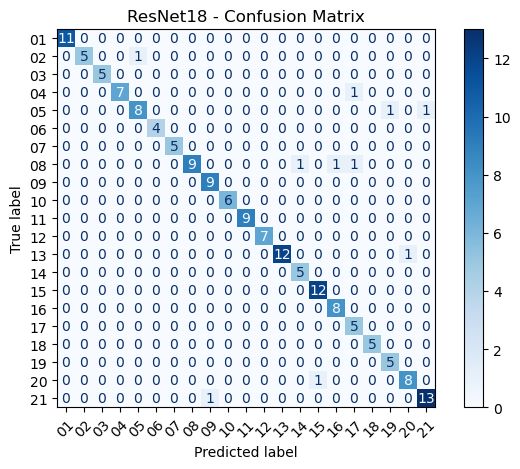

In [ ]:
best_val_loss = float('inf')
no_improve = 0
max_epochs = 30
patience = 6

for epoch in range(1, max_epochs + 1):
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # validation
    model.eval()
    val_loss = 0
    metric_acc.reset()
    metric_precision.reset()
    metric_recall.reset()
    metric_f1.reset()

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            metric_acc.update(preds, labels)
            metric_precision.update(preds, labels)
            metric_recall.update(preds, labels)
            metric_f1.update(preds, labels)

    val_loss /= len(val_loader)
    val_acc = metric_acc.compute()
    val_prec = metric_precision.compute()
    val_rec = metric_recall.compute()
    val_f1 = metric_f1.compute()
    scheduler.step(val_loss)

    print(f"Epoch {epoch}/{max_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}, Precision: {val_prec:.4f}, Recall: {val_rec:.4f}, F1: {val_f1:.4f}")

    # Save the best training model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc.item()
        best_val_f1 = val_f1.item()
        no_improve = 0
        torch.save(model.state_dict(), "85_classification_resnet18.pth")
        print("Best model saved!")
    else:
        no_improve += 1
        if no_improve >= patience:
            print("Early stopping triggered!")
            break


# loading the model
model.load_state_dict(torch.load("85_classification_resnet18.pth"))
model.eval()

# collect prediction
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Building confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# visible confusion matrix
print(f"\nBest Val Accuracy: {best_val_acc * 100:.2f}%")
print(f"Final F1-score: {best_val_f1:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45, values_format='d')
plt.title("ResNet18 - Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.show()


C:\Users\23771\AppData\Local\Temp\ipykernel_38560\203138927.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("85_classification_resnet18.

Predicted class: 11


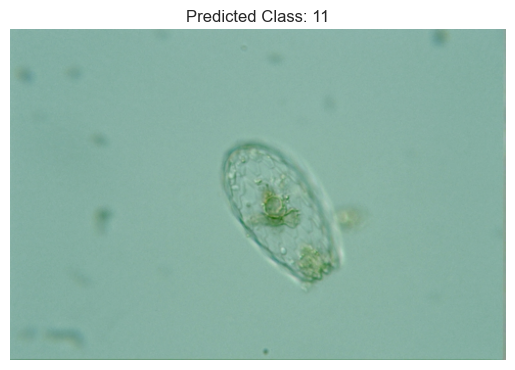

In [ ]:
#Testing model
# Loading the saved model
model.load_state_dict(torch.load("85_classification_resnet18.pth", map_location=device))
model.eval()

# Test a specific image
image_path = "EMDS-6/EMDS5-Original/07/EMDS5-g07-02.png"
image = Image.open(image_path).convert("RGB")
img_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(img_tensor)
    pred = torch.argmax(output, dim=1).item()

print(f"Predicted class: {class_names[pred]}")
plt.imshow(image)
plt.title(f"Predicted Class: {class_names[pred]}")
plt.axis('off')
plt.show()
